# 02 — Exploratory Data Analysis (FD001)

**Phase 3 — FD001 Exploration**

Goals:
- Operational settings distribution
- Sensor distributions (all 21 sensors)
- Identify constant / near-constant sensors
- Sensor correlation analysis

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.data.ingestion import DataIngestion
from src.entity.config_entity import DataIngestionConfig
from src.config.config import SENSOR_COLUMNS, SETTING_COLUMNS

sns.set_theme(style='whitegrid')

VARIANT = 'FD001'
data = DataIngestion(DataIngestionConfig(variant=VARIANT)).run(persist=False)
train_df = data['train']
train_df.shape

[2026-08-27 21:55:49] INFO     | src.data.ingestion | Loaded train_FD001.txt -> shape=(20631, 26), engines=100
[2026-08-27 21:55:49] INFO     | src.data.ingestion | Loaded test_FD001.txt -> shape=(13096, 26), engines=100
[2026-08-27 21:55:50] INFO     | src.data.ingestion | Loaded RUL_FD001.txt -> shape=(100, 2)


(20631, 26)

## Operational settings
FD001 has a single operating condition, so settings should show very little spread compared to FD002/FD004.

In [2]:
train_df[SETTING_COLUMNS].describe()

,setting_1,setting_2,setting_3
count,20631.000000,20631.000000,20631.0
mean,-0.000009,0.000002,100.0
std,0.002187,0.000293,0.0
min,-0.008700,-0.000600,100.0
25%,-0.001500,-0.000200,100.0
50%,0.000000,0.000000,100.0
75%,0.001500,0.000300,100.0
max,0.008700,0.000600,100.0


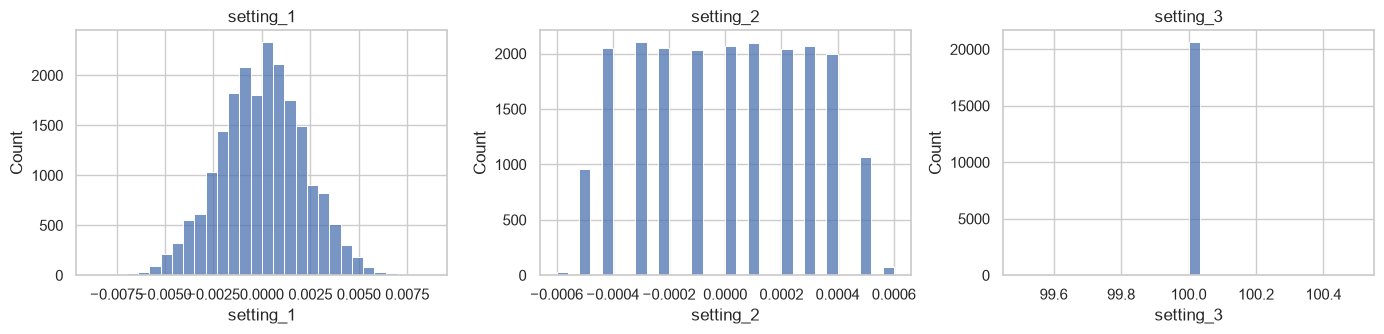

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, SETTING_COLUMNS):
    sns.histplot(train_df[col], bins=30, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Sensor distributions
Plot all 21 sensors to spot near-constant, noisy, or skewed signals.

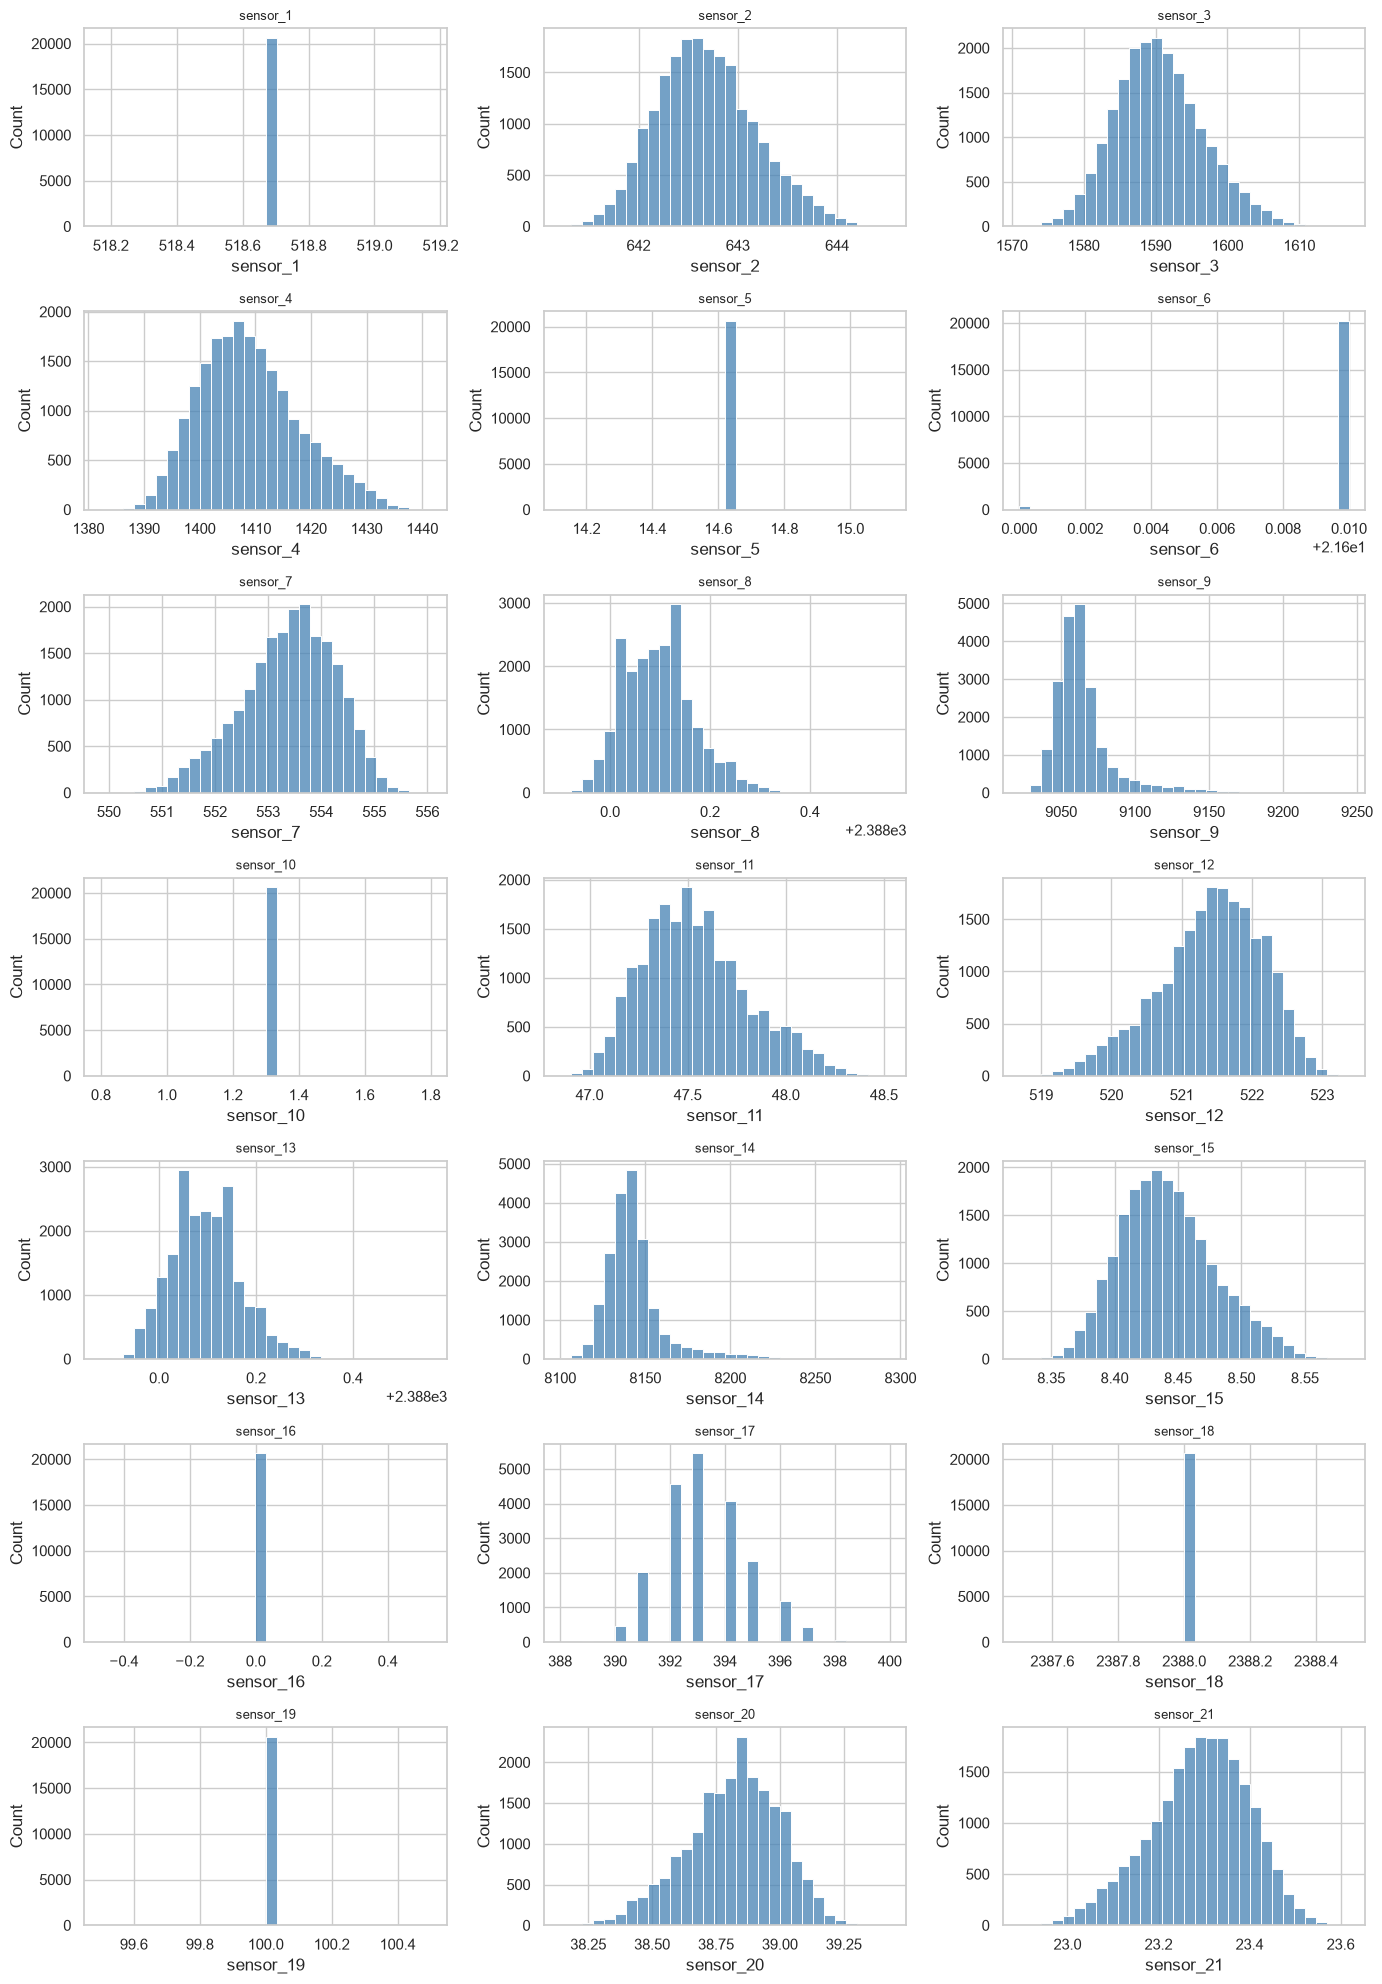

In [5]:
fig, axes = plt.subplots(7, 3, figsize=(14, 20))
for ax, col in zip(axes.flatten(), SENSOR_COLUMNS):
    sns.histplot(train_df[col], bins=30, ax=ax, color='steelblue')
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

## Identify constant / near-constant sensors
Sensors with (near) zero variance carry little predictive signal for FD001 and are candidates for exclusion in feature engineering (Phase 5).

In [6]:
sensor_std = train_df[SENSOR_COLUMNS].std().sort_values()
sensor_std

sensor_1     0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_10    0.000000e+00
sensor_16    3.469531e-18
sensor_5     5.329200e-15
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64

In [7]:
near_constant = sensor_std[sensor_std < 1e-3].index.tolist()
print('Near-constant sensors:', near_constant)

Near-constant sensors: ['sensor_1', 'sensor_19', 'sensor_18', 'sensor_10', 'sensor_16', 'sensor_5']


## Sensor correlation matrix

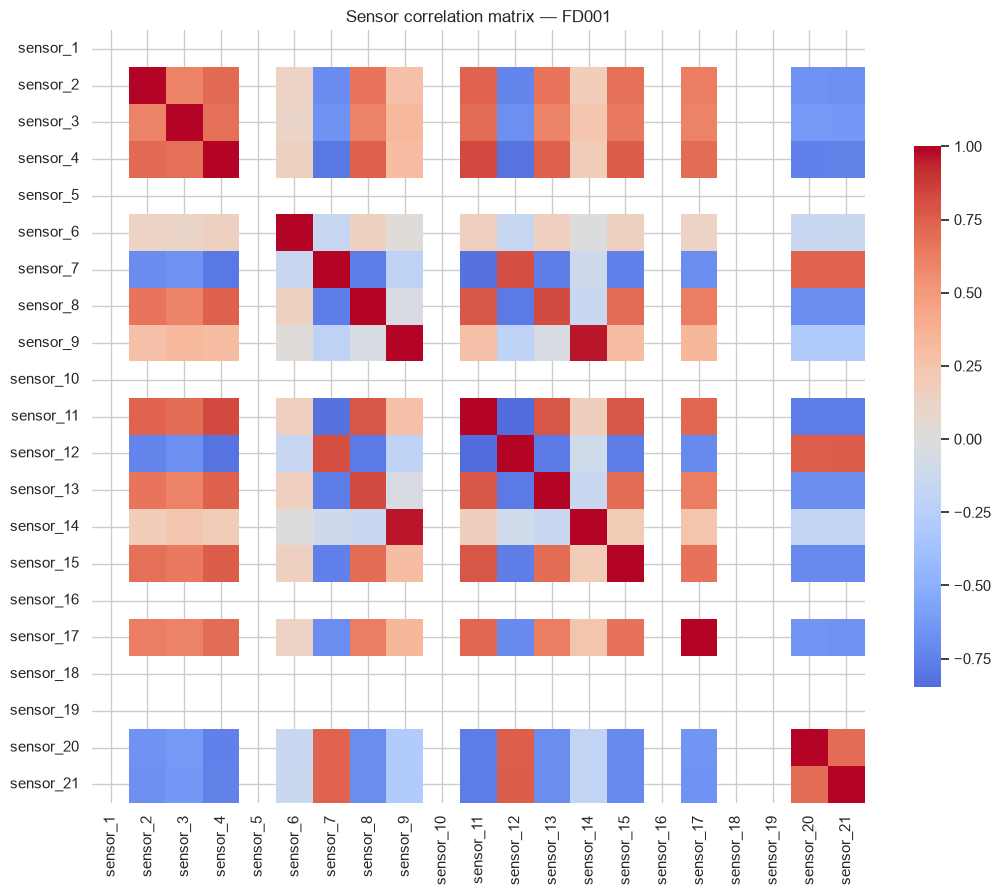

In [8]:
corr = train_df[SENSOR_COLUMNS].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True,
            cbar_kws={'shrink': 0.7})
plt.title('Sensor correlation matrix — FD001')
plt.tight_layout()
plt.show()

## Highly correlated sensor pairs
Pairs above a correlation threshold may be redundant.

In [9]:
import numpy as np

corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
)
corr_pairs.columns = ['sensor_a', 'sensor_b', 'correlation']
corr_pairs = corr_pairs.reindex(
    corr_pairs['correlation'].abs().sort_values(ascending=False).index
)
corr_pairs.head(15)

,sensor_a,sensor_b,correlation
181,sensor_9,sensor_14,0.963157
221,sensor_11,sensor_12,-0.846884
73,sensor_4,sensor_11,0.830136
159,sensor_8,sensor_13,0.826084
136,sensor_7,sensor_11,-0.822805
74,sensor_4,sensor_12,-0.815591
137,sensor_7,sensor_12,0.812713
69,sensor_4,sensor_7,-0.793130
243,sensor_12,sensor_13,-0.788441
158,sensor_8,sensor_12,-0.786540


## Next
Continue to **03_sensor_analysis.ipynb** to link sensor behavior directly to degradation and proximity to failure.